In [1]:
%matplotlib inline

**Marginal Fitting: Current Education**

**Comments**: 
* "current_edu" is fixed to match the proportions per age in the 2017 SynPop
* the choice of agents to change is random

In [2]:
import logging
import os
import sys

from matplotlib import pyplot as plt
import pandas as pd

In [3]:
sys.path.append(r'X:\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.visualisations import save_figure, plot_multi_class_feature_per_age, plot_ct1, plot_ct2, plot_ct3
from synpop import marginal_fitting, utils
from synpop.synpop import Persons

In [5]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set logging level: WARNING, INFO, DEBUG

# Settings

In [6]:
YEAR_IST = 2017
YEAR = 2040

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, 'persons_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Export Settings**

In [7]:
SAVE_OUTPUTS = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [8]:
utils.create_dir(OUTPUT_DIR)

2020-04-20 18:15:22,297 - INFO - synpop.utils: "./outputs" exists already


# Loading Data

## SynPop

In [9]:
COLUMNS_OF_INTEREST = ['person_id', 'level_of_employment', 'position_in_bus', 'position_in_edu', 'age', 'location_id', 
                       'is_employed', 'loe_group', 'current_edu', 'current_job_rank', 'is_apprentice', 
                       'KT', 'N_KT', 'ID_Gem', 'N_Gem', 'KT_full' ]

In [10]:
COLOUR_DICT = {'kindergarten': 'k', 'pupil_primary': 'C0', 'pupil_secondary': 'C1', 'student': 'C2',
               'apprentice': 'C3',  'null': 'grey'}

**Scenario Year**

In [11]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2040\\02_preprocessed\\persons_2040.pickle.gzip'

In [12]:
%%time
synpop_persons = Persons(YEAR)
synpop_persons.load_pickle(SYNPOP_PERSONS_FILE)

persons = synpop_persons.data[COLUMNS_OF_INTEREST].copy(deep=True)

del synpop_persons

2020-04-20 18:15:22,352 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2040\02_preprocessed\persons_2040.pickle.gzip ...
2020-04-20 18:15:36,438 - INFO - synpop.synpop: Table persons loaded with 10037464 rows.


Wall time: 20.3 s


**Year IST**

In [13]:
SYNPOP_PERSONS_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\persons_2017.pickle.gzip'

In [14]:
%%time
synpop_persons_ist = Persons(YEAR_IST)
synpop_persons_ist.load_pickle(SYNPOP_PERSONS_FILE_IST)

persons_ist = synpop_persons_ist.data[COLUMNS_OF_INTEREST].copy(deep=True)

del synpop_persons_ist

2020-04-20 18:15:42,705 - INFO - synpop.synpop: Loading \\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed\persons_2017.pickle.gzip ...
2020-04-20 18:16:00,436 - INFO - synpop.synpop: Table persons loaded with 8560151 rows.


Wall time: 23.9 s


In [15]:
print('Imported data:')
print('persons DataFrame for {}: {}'.format(YEAR_IST, persons_ist.shape))
print('persons DataFrame for {}: {}'.format(YEAR, persons.shape))

Imported data:
persons DataFrame for 2017: (8560151, 16)
persons DataFrame for 2040: (10037464, 16)


# Examining SynPop-raw

In [16]:
ORDERED_CATEGORIES = list(persons['current_edu'].cat.categories)

## Global Counts

In [17]:
%%time
summary_table = marginal_fitting.compute_comparison_summary(persons, persons_ist, 
                                                            YEAR, YEAR_IST, 
                                                            groupby='current_edu')

2020-04-20 18:16:18,166 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


Wall time: 11.6 s


In [18]:
print('As reference, the total population growth is: {:.2f}'.format(persons.shape[0] / persons_ist.shape[0]))
summary_table

As reference, the total population growth is: 1.17


,counts_2017,counts_2040,growth,prop_2017,prop_2040
current_edu,,,,,
kindergarten,0,0,0.00,0.00,0.00
pupil_primary,468584,497172,1.06,0.05,0.05
pupil_secondary,476812,349988,0.73,0.06,0.03
student,295936,287724,0.97,0.03,0.03
apprentice,184450,406485,2.20,0.02,0.04
null,7134369,8496095,1.19,0.83,0.85


## Marginals Per Age

In [19]:
%%time 
marginals = marginal_fitting.compute_ist_vs_scenario_marginal_counts(persons, persons_ist,
                                                                     YEAR, YEAR_IST, 
                                                                     feature='current_edu', 
                                                                     control_level_list=['age'])

Wall time: 16.1 s


**Scenario Year**

In [20]:
counts_per_cat = (marginals
                  .reset_index()
                  .pivot(index='age', columns='current_edu', values=f'counts_{YEAR}')
                  )
counts_per_cat = counts_per_cat[ORDERED_CATEGORIES]

2020-04-20 18:16:36,536 - INFO - root: Figure saved to file : ./outputs\03_SynPop2040_raw_current_edu_by_age.png


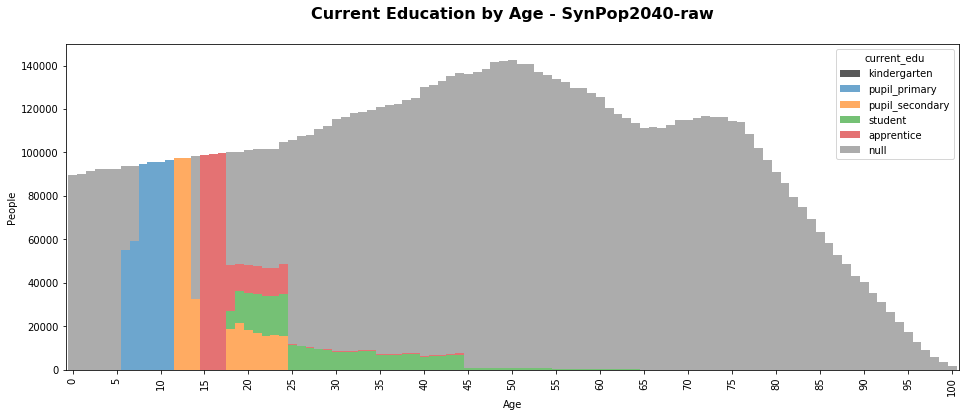

In [21]:
title = 'Current Education by Age - SynPop{}-raw'.format(YEAR)

ax = plot_multi_class_feature_per_age(counts_per_cat, colour_dict=COLOUR_DICT, ymax=150_000, title=title)

save_figure(SAVE_OUTPUTS, '03_SynPop{}_raw_current_edu_by_age.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**Year IST**

In [22]:
counts_per_cat_ist = (marginals
                      .reset_index()
                      .pivot(index='age', columns='current_edu', values='counts_{}'.format(YEAR_IST))
                      )
counts_per_cat_ist = counts_per_cat_ist[ORDERED_CATEGORIES]

2020-04-20 18:16:39,833 - INFO - root: Figure saved to file : ./outputs\03_SynPop2017_current_edu_by_age.png


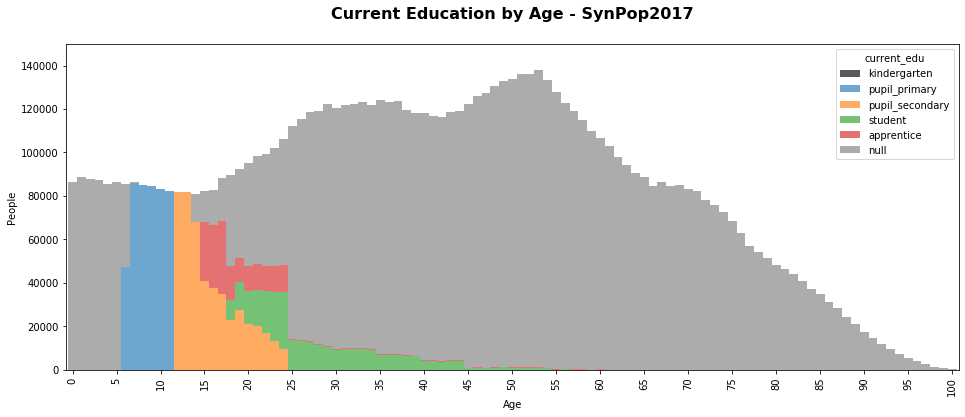

In [23]:
title = f'Current Education by Age - SynPop{YEAR_IST}'

ax = plot_multi_class_feature_per_age(counts_per_cat_ist, colour_dict=COLOUR_DICT, ymax=150_000, title=title)

save_figure(SAVE_OUTPUTS, f'03_SynPop{YEAR_IST}_current_edu_by_age.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

## Cross-Relationships

**Scenario Year**

**CT1**

2020-04-20 18:16:49,965 - INFO - root: Figure saved to file : ./outputs\03_CT1_SynPop2040_raw.png


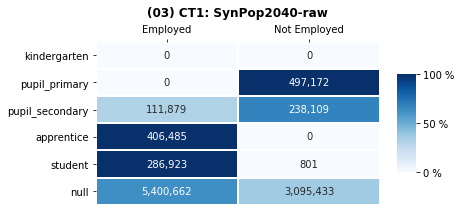

In [24]:
ax, _ = plot_ct1(persons, title=f'(03) CT1: SynPop{YEAR}-raw')

save_figure(SAVE_OUTPUTS, f'03_CT1_SynPop{YEAR}_raw.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT2**

2020-04-20 18:16:57,984 - INFO - root: Figure saved to file : ./outputs\03_CT2_SynPop2040_raw.png


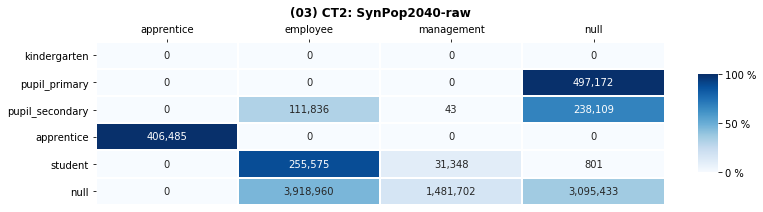

In [25]:
ax, _ = plot_ct2(persons, title=f'(03) CT2: SynPop{YEAR}-raw')

save_figure(SAVE_OUTPUTS, f'03_CT2_SynPop{YEAR}_raw.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT3**

2020-04-20 18:17:06,791 - INFO - root: Figure saved to file : ./outputs\03_CT3_SynPop2040_raw.png


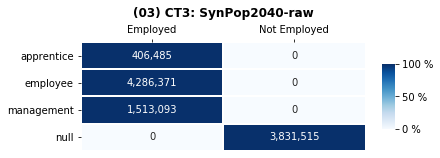

In [26]:
ax, _ = plot_ct3(persons, title=f'(03) CT3: SynPop{YEAR}-raw')

save_figure(SAVE_OUTPUTS, f'03_CT3_SynPop{YEAR}_raw.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**Year IST**

**CT1**

2020-04-20 18:17:14,165 - INFO - root: Figure saved to file : ./outputs\03_CT1_SynPop2017.png


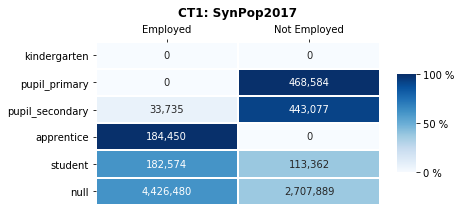

In [27]:
ax, _ = plot_ct1(persons_ist, title=f'CT1: SynPop{YEAR_IST}')

save_figure(SAVE_OUTPUTS, f'03_CT1_SynPop{YEAR_IST}.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT2**

2020-04-20 18:17:20,867 - INFO - root: Figure saved to file : ./outputs\03_CT2_SynPop2017.png


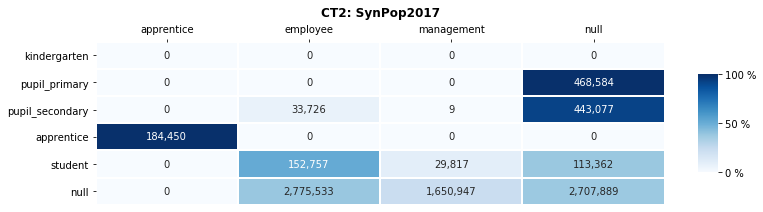

In [28]:
ax, _ = plot_ct2(persons_ist, title=f'CT2: SynPop{YEAR_IST}')

save_figure(SAVE_OUTPUTS, f'03_CT2_SynPop{YEAR_IST}.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT3**

2020-04-20 18:17:27,693 - INFO - root: Figure saved to file : ./outputs\03_CT3_SynPop2017.png


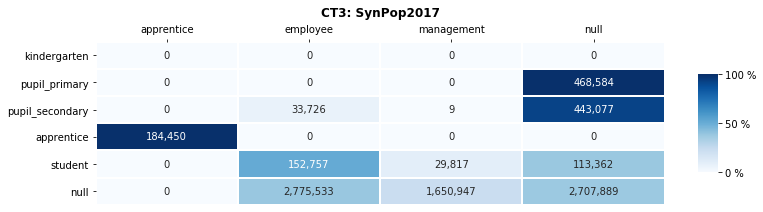

In [29]:
ax, _ = plot_ct2(persons_ist, title=f'CT3: SynPop{YEAR_IST}')

save_figure(SAVE_OUTPUTS, f'03_CT3_SynPop{YEAR_IST}.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

# Fixing Methodology

## Expected Counts

Defining the Control Totals:
* The structure per age of 2017 is reproduced.
* The categories that have a global scaling factor enforced are scaled accordingly.
* At least one category needs to have no global scaling factor to allow balance.  

In [30]:
%%time 
marginals = marginal_fitting.compute_ist_vs_scenario_marginal_summary_table(persons, persons_ist,
                                                                            YEAR, YEAR_IST, 
                                                                            'current_edu', 
                                                                            ['age']
                                                                           )

2020-04-20 18:17:48,469 - INFO - synpop.marginal_fitting: The following segments have no data in ist and will stay untouched: Int64Index([110, 111, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 123,
            124, 125, 126, 127, 128, 129, 131, 132],
           dtype='int64', name='age')


Wall time: 21.1 s


In [31]:
expected_summary = marginals.reset_index().groupby('current_edu').sum()[[f'counts_{YEAR_IST}', f'expected_counts_{YEAR}']]

expected_summary[f'expected_growth_{YEAR}'] = (expected_summary[f'expected_counts_{YEAR}'] / expected_summary[f'counts_{YEAR_IST}']).fillna(0)

In [32]:
expected_summary

,counts_2017,expected_counts_2040,expected_growth_2040
current_edu,,,
apprentice,184450,204095,1.106506
kindergarten,0,0,0.000000
null,7134369,8457865,1.185510
pupil_primary,468584,528024,1.126850
pupil_secondary,476812,550066,1.153633
student,295936,297320,1.004677


The BFS predicts a significant shift with a lot more people going into higher education. Sources:
* https://www.bfs.admin.ch/bfs/fr/home/statistiques/education-science/scenarios-systeme-formation.assetdetail.6826155.html
* https://www.bfs.admin.ch/bfs/de/home/statistiken/kataloge-datenbanken/daten.gnpdetail.2015-0423.html

The trends were extended from 2037 to 2040 to the following global evolutions:
* Pupil Primary: + 18%
* Pupil Secondary: + 24%
* Students: + 24%
* Apprentice: No numbers but the current proportions will probably not grow. 

It was decided that we do not mess too much with the number of pupils but do increas students a bit more. 
We will enforce:
* Pupil Primary: No control totals, it only depends on age
* Pupil Secondary: We leave the +15% due to population growth
* Students: We compromise by forcing a **+15%** increase (take them from current_edu == "null")

In [33]:
expected_summary

,counts_2017,expected_counts_2040,expected_growth_2040
current_edu,,,
apprentice,184450,204095,1.106506
kindergarten,0,0,0.000000
null,7134369,8457865,1.185510
pupil_primary,468584,528024,1.126850
pupil_secondary,476812,550066,1.153633
student,295936,297320,1.004677


In [34]:
delta_students = expected_summary.loc['student', f'counts_{YEAR_IST}'] * 1.15 - expected_summary.loc['student', f'expected_counts_{YEAR}']
delta_students = delta_students.astype(int)
print(f'In order to reach the 15% growth, we need {delta_students} more students in {YEAR}')

In order to reach the 15% growth, we need 43006 more students in 2040


* The additional students are distributed to the age groups based on the proportion of students they already have.
* Geographically, the additional students are distributed randomly. They will hence end up more in areas that are dense in key student demographics, which is exactly what we want.   

Sanity Check: Total students that will be added to the marginal: 43006


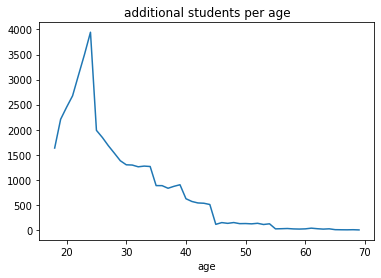

In [35]:
students_per_age = marginals['expected_counts_2040'].loc[:, 'student']
persons_per_age = marginals['expected_counts_2040'].groupby(level='age').sum()

prop_students_per_age = (students_per_age / persons_per_age).fillna(0)

additional_students_per_age = prop_students_per_age.sample(delta_students, weights=prop_students_per_age, replace=True).index.value_counts()
additional_students_per_age.index.name = 'age'
additional_students_per_age.name = 'additional_students'

print(f'Sanity Check: Total students that will be added to the marginal: {additional_students_per_age.sum()}')
_ = additional_students_per_age.sort_index().plot(title='additional students per age')

Going in and forcing the student marginals we want:
* Add more students 
* Remove equivalent "null"

In [36]:
expected_counts_students = marginals.reset_index().query('current_edu == "student"').set_index('age')[f'expected_counts_{YEAR}']
students_per_age = pd.concat([expected_counts_students, additional_students_per_age], axis=1).fillna(0).astype(int)

new_expected_counts_students = students_per_age[f'expected_counts_{YEAR}'] + students_per_age['additional_students']

expected_counts_null = marginals.reset_index().query('current_edu == "null"').set_index('age')[f'expected_counts_{YEAR}']
nulls_per_age = pd.concat([expected_counts_null, additional_students_per_age], axis=1).fillna(0).astype(int)

new_expected_counts_null = nulls_per_age[f'expected_counts_{YEAR}'] - nulls_per_age['additional_students']

In [37]:
def replace_stundent_marginals(original_marginals, column_name, new_student_counts, new_null_counts):
    new_marginals = original_marginals.copy(deep=True)

    mask_students = new_marginals.index.get_level_values(1) == 'student'
    new_marginals[column_name] = new_marginals[column_name].mask(mask_students, new_student_counts)

    mask_nulls = new_marginals.index.get_level_values(1) == 'null'
    new_marginals[column_name] = new_marginals[column_name].mask(mask_nulls, new_null_counts)
    
    return new_marginals

In [38]:
marginals_with_more_students = replace_stundent_marginals(marginals, 
                                                          column_name=f'expected_counts_{YEAR}',
                                                          new_student_counts=new_expected_counts_students,
                                                          new_null_counts=new_expected_counts_null
                                                         )

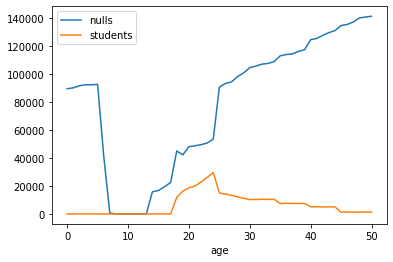

In [39]:
# Sanity checking:
_ = pd.concat([marginals_with_more_students[f'expected_counts_{YEAR}'].loc(axis=0)[:, 'null'].droplevel(1).rename('nulls'),
               marginals_with_more_students[f'expected_counts_{YEAR}'].loc(axis=0)[:, 'student'].droplevel(1).rename('students')
               ], axis=1).loc[:50].plot()

In [40]:
pop_per_age_before = marginals.groupby(level='age').sum()[f'expected_counts_{YEAR}']
pop_per_age_after = marginals_with_more_students.groupby(level='age').sum()[f'expected_counts_{YEAR}']

assert ((pop_per_age_after - pop_per_age_before) == 0).all(), 'The pop per age has changes after applying the new control totals!'

Carrying on with the new marginals...

In [41]:
expected_pop_counts = (marginals_with_more_students[f'expected_counts_{YEAR}'].rename('expected_counts')
                       .reset_index()
                       .pivot(index='age', columns='current_edu', values='expected_counts')
                       )[ORDERED_CATEGORIES]

## Probabiltiy Model

Why we use a proba model here:
* Based on how "current_edu" is defined, some information about the original "position_in_edu" is lost.
* When we want to change "current_edu" from "apprentice" to something else, using the original "position_in_edu" can help.
* This allows some of the realistic values from the raw-synpop to be maintained.

In [42]:
ct_edu_ist =  marginal_fitting.compute_cross_table(persons_ist,
                                                   main_feature='current_edu',
                                                   secondary_features='position_in_edu'
                                                   )

In [43]:
print('This show just the definition of "current_edu" but we can use it for a smarter fitting.')
ct_edu_ist

This show just the definition of "current_edu" but we can use it for a smarter fitting.


current_edu,kindergarten,pupil_primary,pupil_secondary,student,apprentice,null
position_in_edu,,,,,,
null,0,0,0,0,14465,7134369
pupil,0,468584,476812,0,169710,0
student,0,0,0,295936,275,0


In [44]:
person_proba = marginal_fitting.build_person_proba_with_from_cross_table(persons, ct_edu_ist, merge_on='position_in_edu')

In [45]:
person_proba

,kindergarten,pupil_primary,pupil_secondary,student,apprentice,null
person_id,,,,,,
1,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,0.002023,9.979766e-01
2,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,0.002023,9.979766e-01
4,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,0.002023,9.979766e-01
5,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,0.002023,9.979766e-01
6,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,0.002023,9.979766e-01
...,...,...,...,...,...,...
14483686,1.000000e-10,4.202148e-01,4.275934e-01,1.000000e-10,0.152192,1.000000e-10
14483687,1.000000e-10,4.202148e-01,4.275934e-01,1.000000e-10,0.152192,1.000000e-10
14483688,1.000000e-10,4.202148e-01,4.275934e-01,1.000000e-10,0.152192,1.000000e-10


## Fixing...

The logging can be set to `INFO` or `DEBUG` (at the top of the notebook `logger.setLevel(logging.INFO)`) based on how much detail is needed!


In [46]:
fixed_edu = marginal_fitting.fix_categorical_feature(persons=persons,
                                                     feature='current_edu',
                                                     pop_segment_variables=['age'],
                                                     control_totals=expected_pop_counts,
                                                     person_proba=person_proba
                                                     )

2020-04-20 18:18:17,036 - INFO - synpop.marginal_fitting: Fixing "current_edu" by population segments based on: ['age']
2020-04-20 18:18:28,118 - INFO - synpop.marginal_fitting: 20 / 132 population segments fixed...
2020-04-20 18:18:29,811 - INFO - synpop.marginal_fitting: 40 / 132 population segments fixed...
2020-04-20 18:18:31,293 - INFO - synpop.marginal_fitting: 60 / 132 population segments fixed...
2020-04-20 18:18:31,887 - INFO - synpop.marginal_fitting: 80 / 132 population segments fixed...
2020-04-20 18:18:32,088 - INFO - synpop.marginal_fitting: 100 / 132 population segments fixed...
2020-04-20 18:18:32,149 - INFO - synpop.marginal_fitting: 120 / 132 population segments fixed...
2020-04-20 18:18:32,234 - INFO - synpop.marginal_fitting: All 132 population segments fixed!


In [47]:
persons_fixed = persons.copy(deep=True)
persons_fixed = persons_fixed.drop('current_edu', axis=1)
persons_fixed = pd.merge(persons_fixed, fixed_edu, left_on='person_id', right_index=True)

In [48]:
persons_fixed.shape

(10037464, 16)

# Examining SynPop+

## Global Counts

In [49]:
%%time
summary_table_fixed = marginal_fitting.compute_comparison_summary(persons_fixed, persons_ist, 
                                                                  YEAR, YEAR_IST, 
                                                                  groupby='current_edu')

Wall time: 13.6 s


In [50]:
print('As reference, the total population growth is: {:.2f}'.format(persons_fixed.shape[0] / persons_ist.shape[0]))
summary_table_fixed

As reference, the total population growth is: 1.17


,counts_2017,counts_2040,growth,prop_2017,prop_2040
current_edu,,,,,
kindergarten,0,0,0.00,0.00,0.00
pupil_primary,468584,528025,1.13,0.05,0.05
pupil_secondary,476812,550066,1.15,0.06,0.05
student,295936,340357,1.15,0.03,0.03
apprentice,184450,204106,1.11,0.02,0.02
null,7134369,8414910,1.18,0.83,0.84


## Marginals Per Age

In [51]:
%%time 
marginals_fixed = marginal_fitting.compute_ist_vs_scenario_marginal_counts(persons_fixed, persons_ist,
                                                                           YEAR, YEAR_IST, 
                                                                           feature='current_edu', 
                                                                           control_level_list=['age']
                                                                           )

Wall time: 16.2 s


In [52]:
marginals_fixed

counts_2017  counts_2040
age current_edu                              
0   apprentice                 0            0
    kindergarten               0            0
    null                   86575        89500
    pupil_primary              0            0
    pupil_secondary            0            0
...                          ...          ...
132 kindergarten               0            0
    null                       0            2
    pupil_primary              0            0
    pupil_secondary            0            0
    student                    0            0

[792 rows x 2 columns]

In [53]:
summary = pd.concat([marginals.reset_index().groupby('current_edu')[f'counts_{YEAR}'].sum().rename(f'SynPop{YEAR}'),
                     marginals_fixed.reset_index().groupby('current_edu')[f'counts_{YEAR}'].sum().rename(f'SynPop{YEAR}-edu+')
                    ], axis=1
                   )

summary['delta_agents'] = summary[f'SynPop{YEAR}-edu+'] - summary[f'SynPop{YEAR}']

In [54]:
summary

,SynPop2040,SynPop2040-edu+,delta_agents
current_edu,,,
apprentice,406485,204106,-202379
kindergarten,0,0,0
null,8496095,8414910,-81185
pupil_primary,497172,528025,30853
pupil_secondary,349988,550066,200078
student,287724,340357,52633


**Year - Fixed**

In [55]:
counts_per_cat_fixed = (marginals_fixed
                        .reset_index()
                        .pivot(index='age', columns='current_edu', values='counts_{}'.format(YEAR))
                        )
counts_per_cat_fixed = counts_per_cat_fixed[ORDERED_CATEGORIES]

2020-04-20 18:19:24,238 - INFO - root: Figure saved to file : ./outputs\03_SynPop2040plus_current_edu_by_age_SMART.png


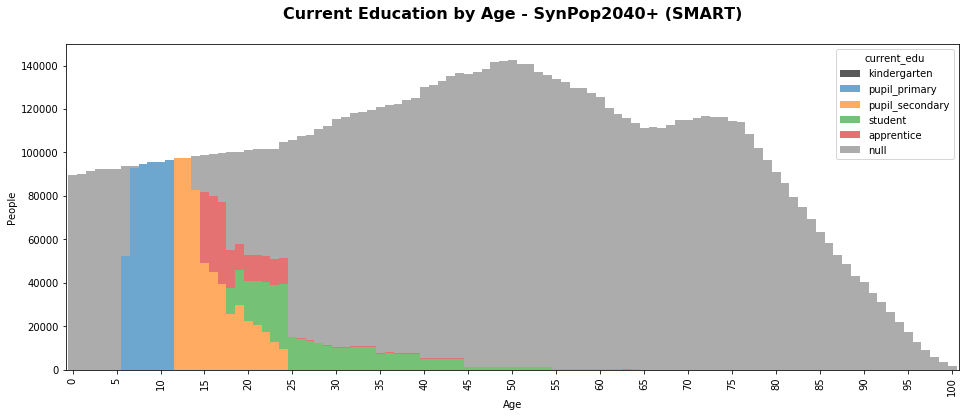

In [56]:
title = 'Current Education by Age - SynPop{}+ (SMART)'.format(YEAR)

ax = plot_multi_class_feature_per_age(counts_per_cat_fixed, colour_dict=COLOUR_DICT, ymax=150_000, title=title)

save_figure(SAVE_OUTPUTS, '03_SynPop{}plus_current_edu_by_age_SMART.{}'.format(YEAR, FIG_FORMAT),
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

## Cross-Relationships

**Issue between 15 and 17 years old**

In [57]:
ct_edu_1517 =  marginal_fitting.compute_cross_table(persons.query('age >= 15').query('age < 18'),
                                                    main_feature='current_edu',
                                                    secondary_features='position_in_edu'
                                                    )

ct_edu_ist_1517 =  marginal_fitting.compute_cross_table(persons_ist.query('age >= 15').query('age < 18'),
                                                       main_feature='current_edu',
                                                       secondary_features='position_in_edu'
                                                       )

ct_edu_fixed_1517 =  marginal_fitting.compute_cross_table(persons_fixed.query('age >= 15').query('age < 18'),
                                                          main_feature='current_edu',
                                                          secondary_features='position_in_edu'
                                                          )

In [58]:
ct_edu_ist_1517

current_edu,kindergarten,pupil_primary,pupil_secondary,student,apprentice,null
position_in_edu,,,,,,
null,0,0,0,0,159,50084
pupil,0,0,113442,0,89505,0
student,0,0,0,0,0,0


In [59]:
ct_edu_1517

current_edu,kindergarten,pupil_primary,pupil_secondary,student,apprentice,null
position_in_edu,,,,,,
null,0,0,0,0,2639,0
pupil,0,0,16,0,294872,0
student,0,0,0,0,0,0


In [60]:
ct_edu_fixed_1517

current_edu,kindergarten,pupil_primary,pupil_secondary,student,apprentice,null
position_in_edu,,,,,,
null,0,0,1022,0,734,883
pupil,0,0,132614,0,104484,57790
student,0,0,0,0,0,0


We see that using the proba model has workd! 
* The large majority of the agents that have been changed to "pupil_secondary" between 15 and 17 years old had "position_in_bus" == "pupil".

**CT1**

2020-04-20 18:19:41,656 - INFO - root: Figure saved to file : ./outputs\03_CT1_SynPop2040_eduPlus_SMART.png


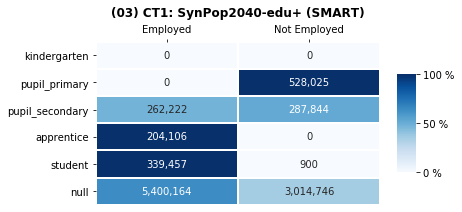

In [61]:
ax, _ = plot_ct1(persons_fixed, title=f'(03) CT1: SynPop{YEAR}-edu+ (SMART)')

save_figure(SAVE_OUTPUTS, f'03_CT1_SynPop{YEAR}_eduPlus_SMART.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT2**

2020-04-20 18:19:49,884 - INFO - root: Figure saved to file : ./outputs\03_CT2_SynPop2040_eduPlus_SMART.png


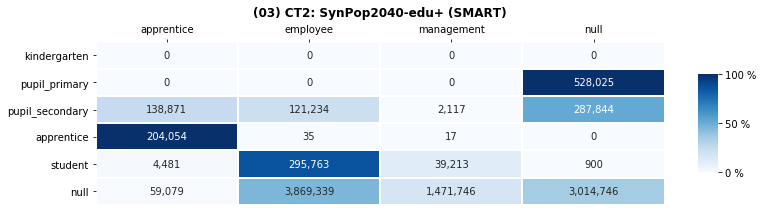

In [62]:
ax, _ = plot_ct2(persons_fixed, title=f'(03) CT2: SynPop{YEAR}-edu+ (SMART)')

save_figure(SAVE_OUTPUTS, f'03_CT2_SynPop{YEAR}_eduPlus_SMART.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

**CT3**

2020-04-20 18:19:56,717 - INFO - root: Figure saved to file : ./outputs\03_CT3_SynPop2040_eduPlus_SMART.png


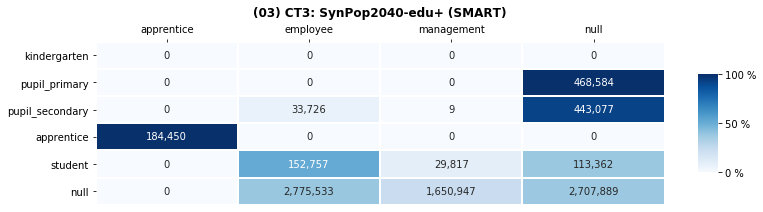

In [63]:
ax, _ = plot_ct2(persons_ist, title=f'(03) CT3: SynPop{YEAR}-edu+ (SMART)')

save_figure(SAVE_OUTPUTS, f'03_CT3_SynPop{YEAR}_eduPlus_SMART.{FIG_FORMAT}',
            OUTPUT_DIR, FIG_DPI, FIG_FORMAT, FIG_BBOX_INCHES, FIG_PAD_INCHES)

# Saving Results

In [64]:
OUTPUT_DIR

'./outputs'

In [65]:
%%time
if SAVE_OUTPUTS:
    results_file = os.path.join(OUTPUT_DIR, 'fixed_current_edu_SMART.pickle.gzip')
    fixed_edu.to_pickle(results_file, compression='gzip')

Wall time: 3min 13s


# Export Notebook to HTML

In [66]:
### Write notebook to a html file
!jupyter nbconvert --to html 03_SMART_Marginal_Fitting_Current_Education.ipynb

[NbConvertApp] Converting notebook 03_SMART_Marginal_Fitting_Current_Education.ipynb to html
[NbConvertApp] Writing 751058 bytes to 03_SMART_Marginal_Fitting_Current_Education.html
